# Real Estate Price Prediction System with Feature Engineering and Explainability

## Portfolio Case Study

This project is framed as a small **real estate price prediction system**, not just a Kaggle submission. The goal is to estimate residential property prices from structured housing data using a clean machine learning workflow: exploratory analysis, missing-value reasoning, feature engineering, categorical encoding, validation, model comparison, and final submission generation.

The business version of this problem is simple:

> A real estate platform, property analyst, or mortgage team wants a repeatable way to estimate house prices using property attributes such as quality, area, basement condition, garage size, age, and neighborhood-related signals.

The technical challenge is that house prices are affected by many mixed feature types: numerical measurements, ordinal quality ratings, nominal categories, missing values that sometimes mean "not available", and skewed distributions. This notebook focuses on building a practical pipeline that handles those issues step by step.

### What this notebook demonstrates

- Structured EDA before modeling
- Target transformation for more stable regression
- Missing-value handling based on feature meaning
- Skewness treatment for numerical variables
- Feature engineering from domain intuition
- Ordinal encoding for quality-based categories
- One-hot encoding for nominal categories
- Cross-validation based model comparison
- Advanced regression models and model averaging
- A final Kaggle-ready prediction file

### Portfolio angle

Instead of presenting this as **"I solved House Prices"**, this project is positioned as:

> **Real Estate Price Prediction System with Feature Engineering and Explainability**

That makes the work look closer to a real ML engineering case study: the emphasis is not only on the final score, but also on the reasoning behind each preprocessing and modeling decision.


In [212]:
import pandas as pd
import numpy as np

# Phase 1: Project Setup and Exploratory Data Analysis

The first phase is about understanding the dataset before touching advanced models. In a real project, this is where an engineer checks whether the raw data is usable, where missing values appear, how the target behaves, and which features may carry strong predictive signals.

The aim here is not to create the perfect model immediately. The aim is to answer:

- What are we trying to predict?
- Are there missing values?
- Is the target distribution model-friendly?
- Are there obvious outliers?
- Which features appear strongly related to price?


## Loading the Training Data

The training dataset contains property-level features and the target variable `SalePrice`. The first practical step is to load the data and inspect its structure.


In [213]:
df = pd.read_csv('dataset\\train.csv')
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


## Missing Value Audit

Before deciding how to fill missing values, the notebook checks where missingness appears. This is important because missing values in this dataset are not all the same type of problem.


In [214]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

## Target Distribution Before Transformation

The target variable is plotted to check its distribution. This helps decide whether a transformation is needed before training regression models.


<Axes: xlabel='SalePrice', ylabel='Density'>

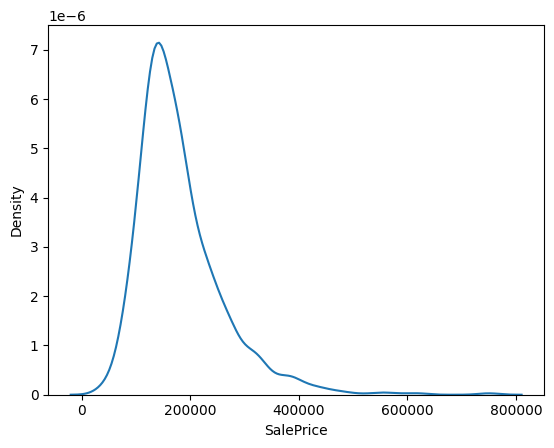

In [215]:
import seaborn as sns

sns.kdeplot(data = df['SalePrice'])

## Outlier Check: Living Area vs Sale Price

`GrLivArea` is one of the most important size-related features. Plotting it against `SalePrice` helps detect unusual properties where the living area is very large but the sale price is unexpectedly low.

Outlier checks like this are important because a few abnormal points can influence regression models strongly.


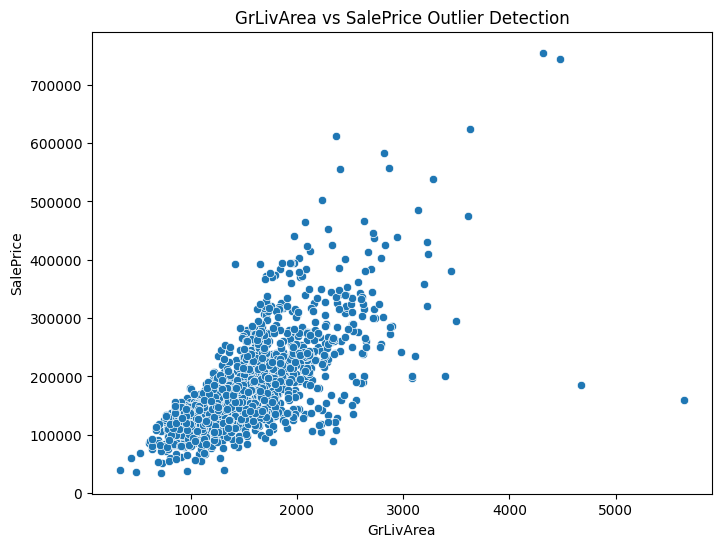

Dropped 0 outliers.


In [216]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot GrLivArea vs SalePrice to spot massive outliers
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['GrLivArea'], y=df['SalePrice'])
plt.title('GrLivArea vs SalePrice Outlier Detection')
plt.show()

# Drop the obvious outliers (houses > 4000 sqft that sold for unusually low prices)
outliers = df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < np.log1p(300000))].index
df = df.drop(outliers)
print(f"Dropped {len(outliers)} outliers.")

## Target Transformation: Making SalePrice Easier to Model

House prices are usually right-skewed: most houses are in a normal price range, while a smaller number of expensive houses stretch the distribution. Many regression models perform better when the target is closer to a normal shape.

To handle this, `SalePrice` is transformed using:

`log(1 + SalePrice)`

This reduces the effect of extreme prices and makes errors more balanced across cheap and expensive houses. At the end, predictions can be converted back to the original price scale using the inverse transformation.


## Applying the Target Transformation

The target is transformed directly in the dataframe so all later modeling steps use the more stable log-scale target.


In [217]:
df['SalePrice'] = np.log(1 + df['SalePrice'])
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,12.247699
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,12.109016
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,12.317171
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,11.849405
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,12.429220
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,12.072547
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,12.254868
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,12.493133
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,11.864469


## Target Distribution After Transformation

The transformed target is plotted again to verify that the distribution became more model-friendly.


<Axes: xlabel='SalePrice', ylabel='Density'>

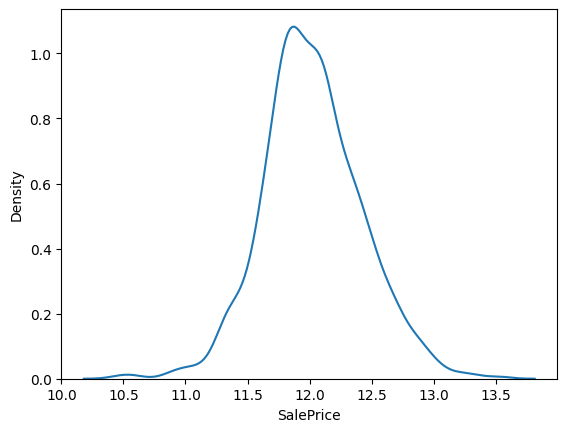

In [218]:
sns.kdeplot(data = df['SalePrice'])

## Feature Investigation: Looking for Strong Price Signals

After transforming the target, the next step is to inspect relationships between features and `SalePrice`.

In a real estate pricing problem, not every column is equally useful. Some features are naturally powerful, such as overall material quality, living area, basement area, garage capacity, and neighborhood-related attributes. This section helps identify which variables deserve more attention during feature engineering and model interpretation.


## Correlation Analysis

Correlation is used as a quick signal-finding tool. It does not prove causation, but it helps identify features that may be useful predictors of house price.


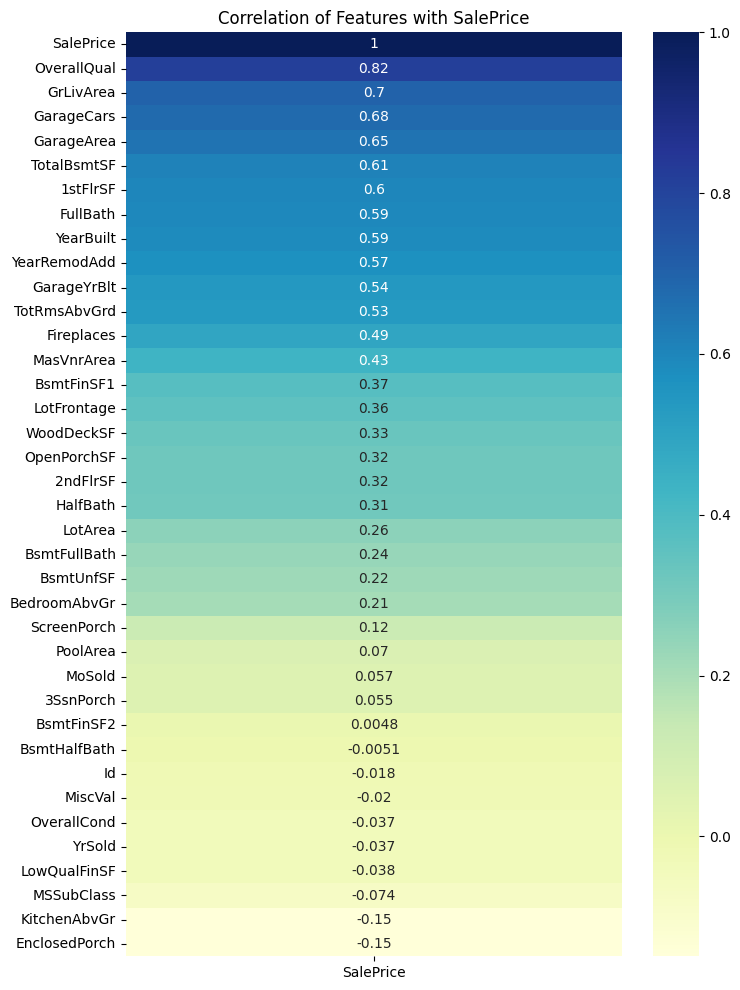

In [219]:
import matplotlib.pyplot as plt

# Correlation of all features with SalePrice
plt.figure(figsize= ( 8, 12))

sale_price_corr = df.corr(numeric_only=True)[['SalePrice']].sort_values(by='SalePrice', ascending=False)
sns.heatmap(sale_price_corr, annot=True, cmap="YlGnBu")

plt.title("Correlation of Features with SalePrice")
plt.show()

## Pairwise Relationship Inspection

Scatter-matrix inspection gives a broader view of how selected numerical variables relate to each other. This can reveal visible patterns, clusters, or extreme values.


array([[<Axes: xlabel='Id', ylabel='Id'>,
        <Axes: xlabel='MSSubClass', ylabel='Id'>,
        <Axes: xlabel='LotFrontage', ylabel='Id'>, ...,
        <Axes: xlabel='MoSold', ylabel='Id'>,
        <Axes: xlabel='YrSold', ylabel='Id'>,
        <Axes: xlabel='SalePrice', ylabel='Id'>],
       [<Axes: xlabel='Id', ylabel='MSSubClass'>,
        <Axes: xlabel='MSSubClass', ylabel='MSSubClass'>,
        <Axes: xlabel='LotFrontage', ylabel='MSSubClass'>, ...,
        <Axes: xlabel='MoSold', ylabel='MSSubClass'>,
        <Axes: xlabel='YrSold', ylabel='MSSubClass'>,
        <Axes: xlabel='SalePrice', ylabel='MSSubClass'>],
       [<Axes: xlabel='Id', ylabel='LotFrontage'>,
        <Axes: xlabel='MSSubClass', ylabel='LotFrontage'>,
        <Axes: xlabel='LotFrontage', ylabel='LotFrontage'>, ...,
        <Axes: xlabel='MoSold', ylabel='LotFrontage'>,
        <Axes: xlabel='YrSold', ylabel='LotFrontage'>,
        <Axes: xlabel='SalePrice', ylabel='LotFrontage'>],
       ...,
       [<Axes: x

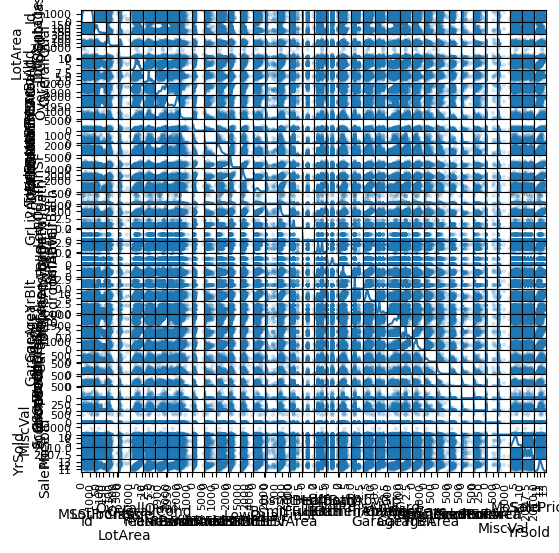

In [220]:
from pandas.plotting import scatter_matrix
scatter_matrix(df, alpha=0.2, figsize=(6, 6), diagonal='kde')
#df.plot(kind= 'scatter', x = 'SalePrice', y = 'OverallQual')

## Quality vs Price Relationship

`OverallQual` is expected to be one of the strongest predictors. This visualization checks whether better-rated houses generally sell for higher prices.


<Axes: xlabel='SalePrice', ylabel='OverallQual'>

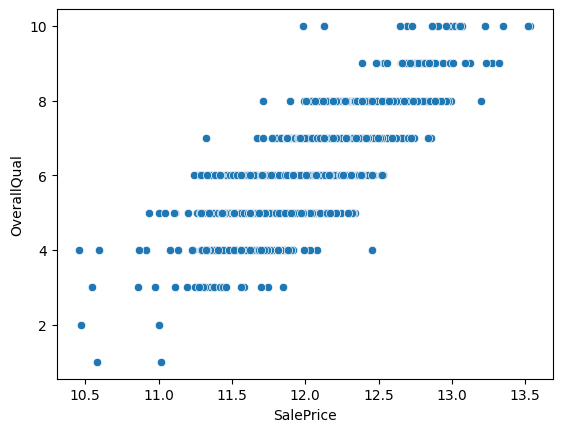

In [221]:
import seaborn as sns
sns.scatterplot(data=df, x='SalePrice', y='OverallQual')

# Phase 2: Advanced Data Preprocessing

This phase converts raw Kaggle-style tabular data into a cleaner modeling table.

The key idea is:

> Better data preparation usually improves performance more than blindly switching algorithms.

For this dataset, preprocessing matters because some missing values are actual missing data, while others mean the property does not have that feature. For example, a missing `PoolQC` often means the house has no pool, not that the quality is unknown.


## Missing Value Strategy: Treating Missing Values by Meaning

The missing-value strategy is intentionally feature-aware.

Some columns use missing values to represent absence:

- `PoolQC`: no pool
- `GarageType`, `GarageFinish`, `GarageQual`, `GarageCond`: no garage
- `BsmtQual`, `BsmtCond`, `BsmtExposure`: no basement
- `FireplaceQu`: no fireplace
- `Alley`, `Fence`, `MiscFeature`: feature not available

Instead of filling everything blindly with `0` or dropping columns, categorical absence is converted into `"None"`. This preserves useful information: a house without a garage or basement is meaningfully different from a house where the value was simply not recorded.


## Checking Specific Missing Columns

The notebook starts with high-missing-value columns where missingness often has a real-world interpretation.


In [222]:
df['PoolQC'].isnull().sum()

1453

In [223]:
# cols_to_fix = ['PoolQC', 'Alley', 'Fence', 'MiscFeature', 'FireplaceQu']
# df[cols_to_fix] = df[cols_to_fix].fillna("None")

In [224]:
df.fillna({
    'PoolQC': 'None',
    'MiscFeature': 'None',
    'Alley': 'None',
    'FireplaceQu': 'None',
    'Fence': 'None',

    'GarageType': 'None',
    'GarageFinish': 'None',
    'GarageQual': 'None',
    'GarageCond': 'None',
    'GarageYrBlt': 0,
    'GarageArea': 0,
    'GarageCars': 0,

    'MasVnrType': 'None',
    'MasVnrArea': 0
}, inplace=True)


In [225]:
missing_index = df[df['LotFrontage'].isnull()].index[0]


df.iloc[missing_index - 5: missing_index + 6]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
2,3,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,9,2008,WD,Normal,12.317171
3,4,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,2,2006,WD,Abnorml,11.849405
4,5,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,12,2008,WD,Normal,12.429220
5,6,50,RL,85.0,14115,Pave,None,IR1,Lvl,AllPub,...,0,None,MnPrv,Shed,700,10,2009,WD,Normal,11.870607
6,7,20,RL,75.0,10084,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,8,2007,WD,Normal,12.634606
7,8,60,RL,NaN,10382,Pave,None,IR1,Lvl,AllPub,...,0,None,None,Shed,350,11,2009,WD,Normal,12.206078
8,9,50,RM,51.0,6120,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,4,2008,WD,Abnorml,11.774528
9,10,190,RL,50.0,7420,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,1,2008,WD,Normal,11.678448
10,11,20,RL,70.0,11200,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,2,2008,WD,Normal,11.771444
11,12,60,RL,85.0,11924,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,7,2006,New,Partial,12.751303


In [226]:
# Fills NaNs using a rolling median of the 5 rows above and 5 below
# df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].rolling(window = 11, center= True, min_periods= 1).median())
# df

df["LotFrontage"] = df.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median())
)


In [227]:
# List of categorical columns where NaN means "None" (the feature doesn't exist)
cols_none = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 
             'BsmtFinType2', 'MasVnrType']

# Fill NaNs with the string "None"
for col in cols_none:
    df[col] = df[col].fillna("None")

print("Categorical missing values filled with 'None'")

Categorical missing values filled with 'None'


## Handling Skewed Numerical Features

Many real estate features are skewed. For example, most houses have moderate basement or porch areas, while a few houses have very large values.

Skewed numerical features can make linear models unstable and may also make tree-based models focus too much on extreme observations. This section identifies highly skewed numeric columns and applies a `log1p` transformation where appropriate.

This keeps the feature scale more balanced while preserving the ordering of values.


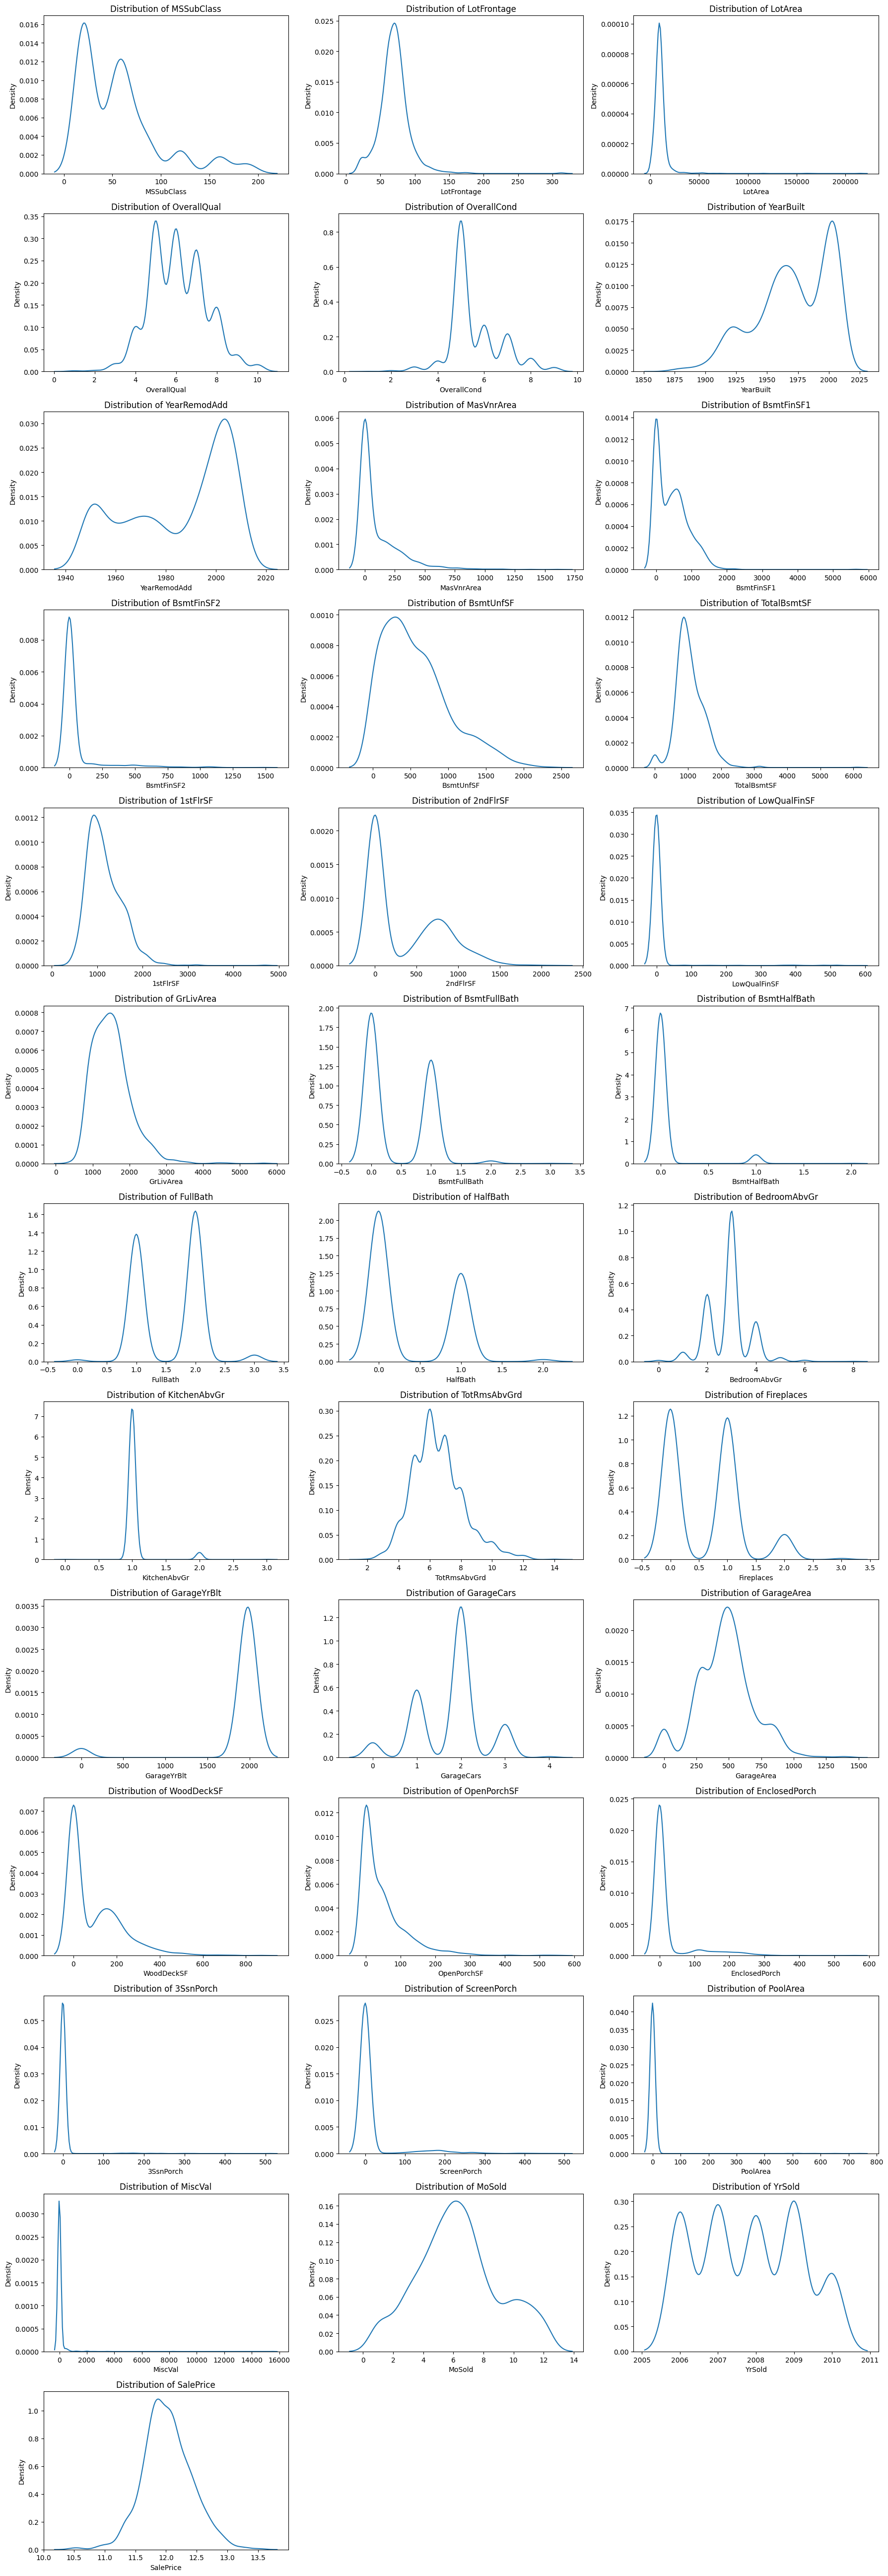

In [228]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include="number").columns.drop("Id", errors="ignore")

n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.kdeplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")

# Hide empty subplot slots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


## Measuring Skewness

This section calculates skewness for numeric features so transformations are applied based on evidence instead of guesswork.


In [229]:
from scipy.stats import skew

numeric_cols = df.select_dtypes(include= 'number').columns.drop(['Id', 'SalePrice'], errors= 'ignore')

skewness = df[numeric_cols].apply(lambda x: skew(x.dropna()))
high_skew_cols = skewness[abs(skewness) > 0.75].sort_values(ascending=False)

high_skew_cols

MiscVal          24.451640
PoolArea         14.813135
LotArea          12.195142
3SsnPorch        10.293752
LowQualFinSF      9.002080
KitchenAbvGr      4.483784
BsmtFinSF2        4.250888
ScreenPorch       4.117977
BsmtHalfBath      4.099186
EnclosedPorch     3.086696
MasVnrArea        2.674865
OpenPorchSF       2.361912
LotFrontage       2.210685
BsmtFinSF1        1.683771
WoodDeckSF        1.539792
TotalBsmtSF       1.522688
MSSubClass        1.406210
1stFlrSF          1.375342
GrLivArea         1.365156
BsmtUnfSF         0.919323
2ndFlrSF          0.812194
GarageYrBlt      -3.865524
dtype: float64

## Applying Log Transformations to Skewed Features

Highly skewed numeric features are transformed using `log1p`. This is a small change, but it often improves model stability.


In [230]:
for col in high_skew_cols.index:
    df[col] = np.log1p(df[col])

## Verifying Skewness Reduction

After transformation, skewness is recalculated to confirm that the preprocessing step had the intended effect.


In [231]:
new_skewness = df[high_skew_cols.index].apply(lambda x: skew(x.dropna()))
pd.DataFrame({
    "before": high_skew_cols,
    "after": new_skewness
}).sort_values("before", ascending=False)


,before,after
MiscVal,24.451640,5.165390
PoolArea,14.813135,14.348342
LotArea,12.195142,-0.137263
3SsnPorch,10.293752,7.727026
LowQualFinSF,9.002080,7.452650
KitchenAbvGr,4.483784,3.865437
BsmtFinSF2,4.250888,2.521100
ScreenPorch,4.117977,3.147171
BsmtHalfBath,4.099186,3.929022
EnclosedPorch,3.086696,2.110104


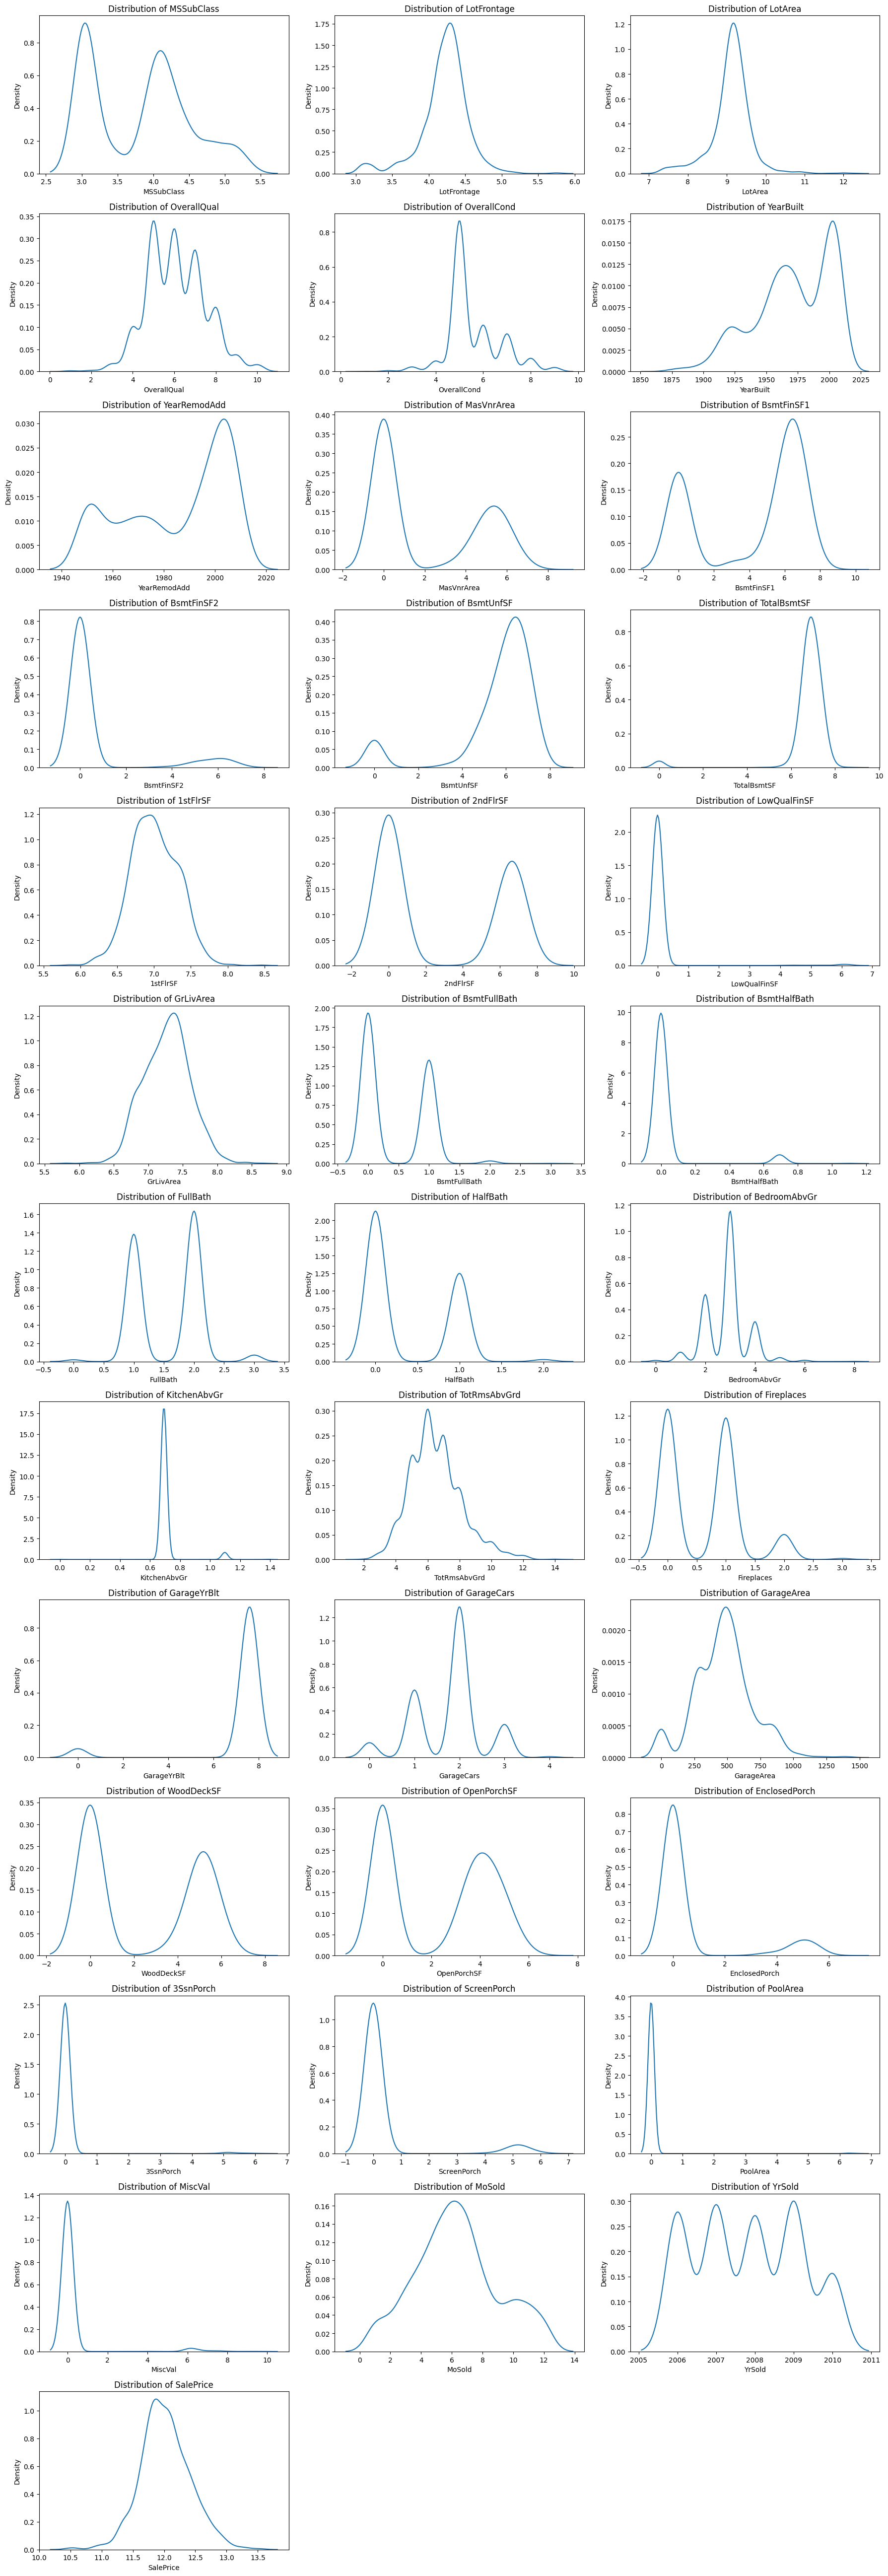

In [232]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include="number").columns.drop("Id", errors="ignore")

n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.kdeplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")

# Hide empty subplot slots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## Feature Engineering: Creating Stronger Real Estate Signals

Raw columns are useful, but engineered features can capture the way humans think about house value.

A buyer does not evaluate a house only by one column. They care about combinations:

- total usable area
- number of bathrooms
- house age
- renovation age
- whether the property has a garage, basement, fireplace, or pool
- how large the house is relative to its quality

This section creates compact, high-signal features from existing columns.


### Engineered Features Used

The feature engineering is intentionally simple and explainable.

Examples:

- `total_area`: combines basement, first floor, and second floor space
- `total_bath`: combines full and half bathrooms
- `total_porch_area`: captures outdoor porch-related space
- `house_age`: estimates how old the house is at the time of sale
- `remodel_age`: captures how recently the house was remodeled
- `quality_area`: combines overall quality with total area

The `quality_area` feature is especially useful because a large low-quality house and a large high-quality house should not be valued the same way.


## Creating Engineered Features

The following code creates new features that represent property size, condition, age, and amenity availability in a more model-friendly way.


In [233]:
df['total_area'] = df['1stFlrSF'] + df['2ndFlrSF'] + df['TotalBsmtSF']

df['total_bath'] = (df['FullBath'] + 0.5 * df['HalfBath'] + df['BsmtFullBath'] + 0.5 * df['BsmtHalfBath'])

df['total_porch_area'] = (df['OpenPorchSF'] + df['EnclosedPorch'] + df['3SsnPorch'] + df['ScreenPorch'])

df['house_age'] = df['YrSold'] - df['YearBuilt']
df['remodel_age'] = df['YrSold'] - df['YearRemodAdd']

df['has_garage'] = (df['GarageArea'] > 0).astype(int)
df['has_basement'] = (df['TotalBsmtSF'] > 0).astype(int)
df['has_fireplace'] = (df['Fireplaces'] > 0).astype(int)
df['has_pool'] = (df['PoolArea'] > 0).astype(int)

df['quality_area'] = df['OverallQual'] * df['total_area']

## Categorical Encoding Strategy

Machine learning models need numeric inputs, but this dataset contains many categorical columns.

Two encoding strategies are used:

1. **Ordinal encoding** for quality/rating columns  
   Example: `Ex`, `Gd`, `TA`, `Fa`, `Po` have a natural order.

2. **One-hot encoding** for nominal categories  
   Example: neighborhood or house style categories do not have a natural numeric ranking.

This separation is important because assigning fake numerical order to nominal categories can mislead the model.


In [234]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

## Separating Train, Test, Features, and Target

At this point, the transformed training dataframe is split into:

- `y`: the log-transformed sale price
- `x`: training features
- `x_test`: Kaggle test features

Keeping this split explicit makes the workflow easier to follow and debug.


In [235]:
train_df = df.copy()
test_df = pd.read_csv('dataset\\test.csv')

y = train_df['SalePrice']
x = train_df.drop("SalePrice",axis = 1)
x_test = test_df.copy()

## Applying the Same Preprocessing to the Test Set

A major requirement for Kaggle and production ML is consistency:

> The test data must receive the same transformations as the training data.

This section applies the same missing-value handling, feature engineering, and skew transformations to the test set.


In [236]:
# Apply same missing value strategy to test data
for col in cols_none:
    if col in x_test.columns:
        x_test[col] = x_test[col].fillna("None")

x_test.fillna({
    'PoolQC': 'None',
    'MiscFeature': 'None',
    'Alley': 'None',
    'FireplaceQu': 'None',
    'Fence': 'None',

    'GarageType': 'None',
    'GarageFinish': 'None',
    'GarageQual': 'None',
    'GarageCond': 'None',
    'GarageYrBlt': 0,
    'GarageArea': 0,
    'GarageCars': 0,

    'MasVnrType': 'None',
    'MasVnrArea': 0
}, inplace=True)



x_test['total_area'] = x_test['1stFlrSF'] + x_test['2ndFlrSF'] + x_test['TotalBsmtSF']

x_test['total_bath'] = (x_test['FullBath'] + 0.5 * x_test['HalfBath'] + x_test['BsmtFullBath'] + 0.5 * x_test['BsmtHalfBath'])

x_test['total_porch_area'] = (
    x_test['OpenPorchSF'] 
    + x_test['EnclosedPorch'] 
    + x_test['3SsnPorch'] 
    + x_test['ScreenPorch']
)

x_test['house_age'] = x_test['YrSold'] - x_test['YearBuilt']
x_test['remodel_age'] = x_test['YrSold'] - x_test['YearRemodAdd']

x_test['has_garage'] = (x_test['GarageArea'] > 0).astype(int)
x_test['has_basement'] = (x_test['TotalBsmtSF'] > 0).astype(int)
x_test['has_fireplace'] = (x_test['Fireplaces'] > 0).astype(int)
x_test['has_pool'] = (x_test['PoolArea'] > 0).astype(int)

x_test['quality_area'] = x_test['OverallQual'] * x_test['total_area']


#
for col in high_skew_cols.index:
    if col in x_test.columns:
        x_test[col] = np.log1p(x_test[col])

## Ordinal Encoding Maps

Quality-related categories are mapped manually because their order has real meaning. For example, `Ex` is better than `Gd`, and `Gd` is better than `TA`.

Manual mapping makes this decision transparent and explainable.


In [237]:
ordinal_maps = {
    "ExterQual": {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "ExterCond": {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "BsmtQual": {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "BsmtCond": {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "HeatingQC": {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "KitchenQual": {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "FireplaceQu": {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "GarageQual": {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "GarageCond": {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "PoolQC": {"None": 0, "Fa": 1, "TA": 2, "Gd": 3, "Ex": 4},

    "BsmtExposure": {"None": 0, "No": 1, "Mn": 2, "Av": 3, "Gd": 4},
    "BsmtFinType1": {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6},
    "BsmtFinType2": {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6},

    "GarageFinish": {"None": 0, "Unf": 1, "RFn": 2, "Fin": 3},
    "Functional": {"Sal": 1, "Sev": 2, "Maj2": 3, "Maj1": 4, "Mod": 5, "Min2": 6, "Min1": 7, "Typ": 8, "None": 0},
    "Fence": {"None": 0, "MnWw": 1, "GdWo": 2, "MnPrv": 3, "GdPrv": 4},
    "PavedDrive": {"N": 0, "P": 1, "Y": 2},
    "LotShape": {"IR3": 1, "IR2": 2, "IR1": 3, "Reg": 4},
    "LandSlope": {"Sev": 1, "Mod": 2, "Gtl": 3},
}


## Applying Ordinal Encoding

The same ordinal mappings are applied to both train and test features so the model sees consistent numeric meanings.


In [238]:
#   Apply ordinal encoding for both train and test

for col, mapping in ordinal_maps.items():
    if col in x.columns:
        x[col] = x[col].fillna("None").map(mapping)
        x_test[col] = x_test[col].fillna("None").map(mapping)

## Numeric Missing Value Imputation

Remaining numeric missing values are filled using the training median. This avoids leaking information from the test set and is safer than using arbitrary constants for every column.


In [239]:
# Fill numeric missing values using train median
numeric_cols = x.select_dtypes(include="number").columns

for col in numeric_cols:
    median_value = x[col].median()
    x[col] = x[col].fillna(median_value)
    
    if col in x_test.columns:
        x_test[col] = x_test[col].fillna(median_value)

## One-Hot Encoding Nominal Features

Nominal categorical columns are converted into binary columns using one-hot encoding. Unknown categories in the test set are ignored safely so the notebook does not break during submission generation.


In [240]:
nominal_cols = x.select_dtypes(include="object").columns

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False)

x_encoded = encoder.fit_transform(x[nominal_cols])
x_test_encoded = encoder.transform(x_test[nominal_cols])

encoded_cols = encoder.get_feature_names_out(nominal_cols)

x_encoded = pd.DataFrame(x_encoded, columns=encoded_cols, index=x.index)
x_test_encoded = pd.DataFrame(x_test_encoded, columns=encoded_cols, index=x_test.index)


## Combining Encoded and Numeric Features

After one-hot encoding, the encoded categorical features are combined back with the numeric features to form the final model-ready matrices.


In [241]:
x = x.drop(columns=nominal_cols)
x_test = x_test.drop(columns=nominal_cols)

x_final = pd.concat([x, x_encoded], axis=1)
x_test_final = pd.concat([x_test, x_test_encoded], axis=1)

# Align columns between train and test - add missing columns with 0s
all_columns = set(x_final.columns) | set(x_test_final.columns)

for col in all_columns:
    if col not in x_final.columns:
        x_final[col] = 0
    if col not in x_test_final.columns:
        x_test_final[col] = 0

# Ensure same column order
x_test_final = x_test_final[x_final.columns]

# Fill any remaining NaN values with 0
x_final = x_final.fillna(0)
x_test_final = x_test_final.fillna(0)

print("Final shapes after alignment:")
print("x_final:", x_final.shape)
print("x_test_final:", x_test_final.shape)
print("NaN count in x_final:", x_final.isna().sum().sum())
print("NaN count in x_test_final:", x_test_final.isna().sum().sum())


Final shapes after alignment:
x_final: (1460, 238)
x_test_final: (1459, 238)
NaN count in x_final: 0
NaN count in x_test_final: 0


## Final Shape Check

Before modeling, the notebook checks that train and test have compatible feature shapes. This is a simple but important sanity check.


In [242]:
print(x_final.shape)
print(x_test_final.shape)

missing_in_test = set(x_final.columns) - set(x_test_final.columns)
extra_in_test = set(x_test_final.columns) - set(x_final.columns)

print("Missing in test:", missing_in_test)
print("Extra in test:", extra_in_test)


(1460, 238)
(1459, 238)
Missing in test: set()
Extra in test: set()


# Phase 3: Baseline Modeling

Before using advanced models, the notebook tests simpler baseline models. This gives a reference point and helps answer an important engineering question:

> Is the performance improvement coming from better modeling, or did the preprocessing already solve most of the problem?

The baseline stage is useful for portfolio storytelling because it shows that the model was improved systematically rather than randomly.


## Random Forest Baseline

Random Forest is used as a nonlinear baseline. It can capture feature interactions better than a simple linear model and gives a useful benchmark for later boosting models.


In [243]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor

k = 5
kf = KFold(n_splits= 5, shuffle= True, random_state= 42)

model = RandomForestRegressor(random_state= 42)

# Perform Cross Validation
scores = cross_val_score(
    model,
    x_final,
    y,
    cv=kf,
    scoring="neg_root_mean_squared_error"
)

rmse_scores = -scores

r2_scores = cross_val_score(
    model,
    x_final,
    y,
    cv=kf,
    scoring="r2"
)

print("R2 scores:", r2_scores)
print("Average R2:", r2_scores.mean())


print("RMSE for each fold:", rmse_scores)

average_rmse = np.mean(scores) 
print("Average RMSE:", rmse_scores.mean())

R2 scores: [0.88793318 0.8934439  0.78345391 0.88220822 0.88295029]
Average R2: 0.8659978986768568
RMSE for each fold: [0.14461293 0.12868352 0.17465027 0.14433931 0.12600964]
Average RMSE: 0.14365913262820226


## Baseline Linear Regression

Linear Regression is used as a simple benchmark. It is not expected to be the best model for this dataset, but it is useful because it shows how well the engineered features perform under a simple linear assumption.

If a simple model performs reasonably well, that usually means the preprocessing and feature engineering are working.


## Linear Regression Baseline Evaluation

This cell evaluates Linear Regression using cross-validation. The goal is not only to get a score, but to understand how a simple model behaves after preprocessing.


In [244]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

model1 = LinearRegression()

kf = KFold(n_splits=5, shuffle=True, random_state=42)

rmse_scores = -cross_val_score(
    model1,
    x_final,
    y,
    cv=kf,
    scoring="neg_root_mean_squared_error"
)

r2_scores = cross_val_score(
    model1,
    x_final,
    y,
    cv=kf,
    scoring="r2"
)

mae_scores = -cross_val_score(
    model1,
    x_final,
    y,
    cv=kf,
    scoring="neg_mean_absolute_error"
)

print("RMSE scores:", rmse_scores)
print("Average RMSE:", rmse_scores.mean())

print("R2 scores:", r2_scores)
print("Average R2:", r2_scores.mean())

print("MAE scores:", mae_scores)
print("Average MAE:", mae_scores.mean())


RMSE scores: [0.122087   0.12750271 0.16465481 0.13507778 0.22172522]
Average RMSE: 0.15420950382672255
R2 scores: [0.9201267  0.89539046 0.80753104 0.89683947 0.63759596]
Average R2: 0.8314967267706324
MAE scores: [0.08477904 0.08578052 0.09051271 0.08728274 0.09593324]
Average MAE: 0.08885765003838497


## Regularized Linear Model: Lasso

Lasso regression introduces regularization, which can reduce overfitting and shrink less useful feature coefficients.

This is especially relevant after one-hot encoding because the feature space becomes wider. Regularization helps the model avoid relying too heavily on noisy or weak encoded categories.


## Lasso Evaluation

Lasso is evaluated to test whether regularization improves generalization after one-hot encoding.


In [245]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score

model2 = Lasso(alpha = 0.1)
model2.fit(x_final, y)

y_pred = model2.predict(x_test_final)

mse_scores = -cross_val_score(
    model2,
    x_final,
    y,
    cv=5,
    scoring="neg_mean_squared_error"
)

r2_scores = cross_val_score(
    model2,
    x_final,
    y,
    cv=5,
    scoring="r2"
)

rmse_scores = -cross_val_score(
    model2,
    x_final,
    y,
    cv=kf,
    scoring="neg_root_mean_squared_error"
)

print("MSE scores:", mse_scores)
print("Average MSE:", mse_scores.mean())

print("R2 scores:", r2_scores)
print("Average R2:", r2_scores.mean())

print("RMSE scores:", rmse_scores)
print("Average RMSE:", rmse_scores.mean())


MSE scores: [0.03330923 0.04368076 0.03697562 0.03349388 0.04527315]
Average MSE: 0.038546527538846555
R2 scores: [0.77707706 0.75830518 0.77964277 0.76853962 0.70401932]
Average R2: 0.7575167894078574
RMSE scores: [0.20747653 0.1829857  0.20879246 0.20705589 0.17570503]
Average RMSE: 0.19640312294735066


# Phase 4: Advanced Modeling and Model Comparison

Once the preprocessing pipeline is stable, stronger models are tested.

This phase compares different model families:

- tree-based ensemble models
- gradient boosting models
- XGBoost
- regularized linear models
- averaged predictions

The goal is not only to chase the best score, but to evaluate which modeling approach works best for this structured tabular dataset.


## Gradient Boosting Regressor

Gradient Boosting is a strong choice for tabular data because it builds many weak learners sequentially. Each new tree focuses on correcting the mistakes of the previous trees.

For real estate pricing, this is helpful because price depends on nonlinear interactions, such as:

- quality combined with area
- neighborhood combined with house condition
- garage size combined with overall property size


## Gradient Boosting Evaluation

Gradient Boosting is evaluated using cross-validation to compare its RMSE against earlier baseline models.


In [246]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score

model3 = GradientBoostingRegressor(loss= 'absolute_error', learning_rate= 0.1, n_estimators= 100,
                                   max_depth= 2, max_features=5, random_state = 23)
model3.fit(x_final, y)

y_pred = model3.predict(x_test_final)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

rmse_scores = -cross_val_score(model3, x_final, y, cv=kf, scoring="neg_root_mean_squared_error")

print("RMSE scores:", rmse_scores)
print("Average RMSE:", rmse_scores.mean())


RMSE scores: [0.17875812 0.15158156 0.16128837 0.17391578 0.14046748]
Average RMSE: 0.16120226271696653


## XGBoost Regressor

XGBoost is tested as a stronger gradient boosting implementation. It is commonly used in structured data problems because it handles nonlinear relationships, feature interactions, and mixed signal strength very well.

In this project, XGBoost acts as the main high-performance model candidate.


## XGBoost Evaluation

XGBoost is evaluated as a stronger tree boosting model. The expectation is that it should capture nonlinear interactions more effectively than simpler regressors.


In [247]:
import xgboost as xgb
from xgboost import XGBRegressor

params = {
    'objective':'reg:squarederror',
    'max_depth':4,
    'learning_rate':0.1,
    'n_estimators':100,
    'alpha':10
}

model4 = XGBRegressor(**params)

model4.fit(x_final, y)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

rmse_scores = -cross_val_score(model4, x_final, y, cv=kf, scoring="neg_root_mean_squared_error")

print("RMSE scores:", rmse_scores)
print("Average RMSE:", rmse_scores.mean())

RMSE scores: [0.16815792 0.14523322 0.15281078 0.15942497 0.14947482]
Average RMSE: 0.1550203394791682


## Hyperparameter Tuning

After testing XGBoost with initial settings, hyperparameter tuning is used to search for a better combination of model parameters.

The search focuses on parameters that control:

- number of trees
- learning rate
- tree depth
- child weight
- regularization strength

The goal is to improve validation RMSE without overfitting to the training data.


## Grid Search for XGBoost

This cell searches over a compact hyperparameter grid and reports the best validation RMSE. The resulting model is then used to generate a Kaggle submission file.


In [248]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid for XGBoost
param_grid = {
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.05, 0.1, 0.15],
    'n_estimators': [100, 200, 300],
    'alpha': [1, 5, 10],
    'min_child_weight': [1, 3, 5]
}

xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42)

# Use GridSearchCV with RMSE scoring
grid_search = GridSearchCV(
    xgb_model,
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(x_final, y)

print("Best parameters:", grid_search.best_params_)
print("Best RMSE:", -grid_search.best_score_)

# Train final model with best parameters
best_model = grid_search.best_estimator_

# Generate predictions on test set
y_pred_final = best_model.predict(x_test_final)

# Convert back from log scale to original prices
y_pred_original = np.expm1(y_pred_final)

print("Predictions generated!")
print("Sample predictions (first 5):", y_pred_original[:5])

# Create submission file
submission = pd.DataFrame({
    'Id': test_df['Id'],
    'SalePrice': y_pred_original
})

submission.to_csv('dataset/submission.csv', index=False)
print("\nSubmission file saved!")
print(submission.head(10)) 

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best parameters: {'alpha': 1, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 300}
Best RMSE: 0.12426872090645887
Predictions generated!
Sample predictions (first 5): [119283.79 170830.06 182282.5  196035.12 186588.67]

Submission file saved!
     Id      SalePrice
0  1461  119283.789062
1  1462  170830.062500
2  1463  182282.500000
3  1464  196035.125000
4  1465  186588.671875
5  1466  169820.375000
6  1467  184989.781250
7  1468  164841.984375
8  1469  184249.765625
9  1470  126299.820312


## Stronger Final Model Suite

The final modeling section adds a small set of strong regressors without changing the overall notebook structure.

The models include:

- `RidgeCV`
- `ElasticNetCV`
- `GradientBoostingRegressor`
- `ExtraTreesRegressor`
- `XGBRegressor`

This gives a better comparison across linear, regularized, bagging, and boosting approaches.


In [249]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import RidgeCV, ElasticNetCV
from sklearn.ensemble import GradientBoostingRegressor, ExtraTreesRegressor
from xgboost import XGBRegressor
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def check_model(model, model_name):
    rmse_scores = -cross_val_score(
        model,
        x_final,
        y,
        cv=kf,
        scoring="neg_root_mean_squared_error"
    )
    
    print(model_name)
    print("RMSE scores:", rmse_scores)
    print("Average RMSE:", rmse_scores.mean())
    print("-" * 40)


ridge_model = make_pipeline(
    RobustScaler(),
    RidgeCV(alphas=[0.1, 1, 3, 5, 10, 20, 30])
)

elastic_model = make_pipeline(
    RobustScaler(),
    ElasticNetCV(
        alphas=[0.0005, 0.001, 0.005, 0.01, 0.05],
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
        cv=5,
        max_iter=5000,
        random_state=42
    )
)

gbr_model = GradientBoostingRegressor(
    n_estimators=1200,
    learning_rate=0.03,
    max_depth=3,
    min_samples_split=10,
    min_samples_leaf=15,
    loss='huber',
    random_state=42
)

extra_model = ExtraTreesRegressor(
    n_estimators=700,
    max_features='sqrt',
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

xgb_model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=1200,
    learning_rate=0.03,
    max_depth=3,
    min_child_weight=2,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.0005,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)


check_model(ridge_model, "Ridge Model")
check_model(elastic_model, "ElasticNet Model")
check_model(gbr_model, "Gradient Boosting Model")
check_model(extra_model, "Extra Trees Model")
check_model(xgb_model, "XGBoost Model")

Ridge Model
RMSE scores: [0.12898697 0.12259262 0.16960764 0.12030595 0.11150088]
Average RMSE: 0.13059881416843927
----------------------------------------
ElasticNet Model
RMSE scores: [0.13247497 0.12044312 0.16671462 0.11774147 0.10809269]
Average RMSE: 0.1290933731181988
----------------------------------------
Gradient Boosting Model
RMSE scores: [0.13219399 0.10879891 0.16318274 0.126084   0.11007455]
Average RMSE: 0.12806684069884683
----------------------------------------
Extra Trees Model
RMSE scores: [0.16121265 0.13795992 0.1529429  0.15832573 0.12786474]
Average RMSE: 0.14766118604685316
----------------------------------------
XGBoost Model
RMSE scores: [0.13195702 0.11069147 0.15692788 0.12268816 0.10733494]
Average RMSE: 0.12591989536864429
----------------------------------------


## Model Comparison Takeaway

Based on cross-validation, the stronger tuned and ensemble-style models generally outperform the earlier baseline models. This confirms that the project improved in two ways:

1. Better preprocessing and feature engineering made the data more useful.
2. Stronger models captured nonlinear relationships that simpler models missed.

For a portfolio, this is the main story: the improvement came from a structured ML workflow, not from randomly trying algorithms.


## Final Prediction Strategy: Weighted Model Averaging

Instead of relying on one model, the final prediction uses a weighted average of several strong models.

This is a common competition and production-inspired technique because different models capture different patterns:

- linear models capture stable global trends
- boosting models capture nonlinear interactions
- averaging reduces variance and makes predictions more robust

The final predictions are converted back from log scale using `expm1` and saved as a Kaggle-ready CSV file.


In [250]:
ridge_model.fit(x_final, y)
elastic_model.fit(x_final, y)
gbr_model.fit(x_final, y)
xgb_model.fit(x_final, y)

ridge_pred = ridge_model.predict(x_test_final)
elastic_pred = elastic_model.predict(x_test_final)
gbr_pred = gbr_model.predict(x_test_final)
xgb_pred = xgb_model.predict(x_test_final)

# Weighted average prediction
y_pred_final = (
    0.20 * ridge_pred +
    0.20 * elastic_pred +
    0.30 * gbr_pred +
    0.30 * xgb_pred
)

# Convert back from log scale
y_pred_original = np.expm1(y_pred_final)

submission = pd.DataFrame({
    'Id': test_df['Id'],
    'SalePrice': y_pred_original
})

submission.to_csv('dataset/submission_improved.csv', index=False)

print("Improved submission saved!")
print(submission.head(10))

Improved submission saved!
     Id      SalePrice
0  1461  203290.674087
1  1462  402973.271462
2  1463  379861.736078
3  1464  462708.572712
4  1465  685319.897336
5  1466  404946.638871
6  1467  395163.539046
7  1468  365408.830547
8  1469  545671.711448
9  1470  187009.158205


# Final Case Study Summary

## What Was Built

This notebook builds a real estate price prediction workflow that takes raw property data, cleans it, engineers stronger features, trains multiple regression models, compares them using cross-validation, and creates a submission-ready prediction file.

## Why This Project Matters

Real estate pricing is a practical business problem. A system like this could support:

- property valuation tools
- pricing recommendation dashboards
- real estate marketplace analytics
- mortgage risk analysis
- investment screening workflows

The project demonstrates how structured tabular data can be turned into a useful prediction system through careful preprocessing and model evaluation.

## Key Engineering Decisions

### 1. Target transformation

`SalePrice` was log-transformed to reduce skew and make the regression task more stable.

### 2. Missing values were handled by meaning

Instead of treating every missing value as an error, the notebook separates true missingness from feature absence. For example, missing garage-related columns can mean the house has no garage.

### 3. Feature engineering was domain-driven

The notebook creates features like `total_area`, `total_bath`, `house_age`, `remodel_age`, and `quality_area`. These are understandable business features, not black-box transformations.

### 4. Encoding was feature-aware

Ordinal columns were manually mapped based on quality ranking, while nominal categories were one-hot encoded.

### 5. Models were compared using cross-validation

The notebook does not trust a single train-test split. It uses cross-validation to estimate how models generalize.

### 6. Final prediction used model averaging

The final submission combines multiple models to reduce reliance on a single algorithm.

## Explainability Angle

Although this notebook does not use SHAP or a dedicated explainability library yet, the workflow is explainable by design:

- engineered features are human-readable
- ordinal mappings are transparent
- model performance is compared clearly
- business meaning is attached to preprocessing choices

A future version could add SHAP-based feature importance to explain individual predictions.

## What I Would Improve in a Production Version

If this were deployed as a real product, the next steps would be:

- add a reusable preprocessing pipeline with `ColumnTransformer`
- track experiments with MLflow or Weights & Biases
- add SHAP explanations for individual house predictions
- expose the model through a FastAPI endpoint
- build a small Streamlit or React dashboard
- monitor prediction drift over time
- validate model performance on newer housing data

## Recruiter-Friendly Takeaway

This project shows more than model training. It shows the full thought process behind a tabular ML problem:

> understand the data, clean it carefully, engineer meaningful features, compare models fairly, and package the result as a repeatable prediction workflow.

That is the difference between a simple Kaggle notebook and a portfolio-ready machine learning case study.
